# Task 2: Customer Segmentation Using Unsupervised Learning
**DevelopersHub Corporation – Advanced Data Science Internship**

## Objective
Cluster customers based on spending habits and propose marketing strategies for each segment.

## Dataset
Mall Customers Dataset (Kaggle)

## Skills Covered
- Unsupervised Learning (K-Means)
- Dimensionality Reduction (PCA, t-SNE)
- Customer Segmentation
- Strategy Development

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded!')

Libraries loaded!


## 1. Loading Dataset
 `Mall_Customers.csv` downloaded from kaggle.

In [5]:
from google.colab import files
uploaded = files.upload()   # Upload Mall_Customers.csv
df = pd.read_csv('Mall_Customers.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Saving Mall_Customers.csv to Mall_Customers (1).csv
Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Dataset Overview & EDA

In [6]:
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nStatistical Summary:')
df.describe()

Shape: (200, 5)

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# Rename columns for easier use
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
print('Columns renamed!')
df.head()

Columns renamed!


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


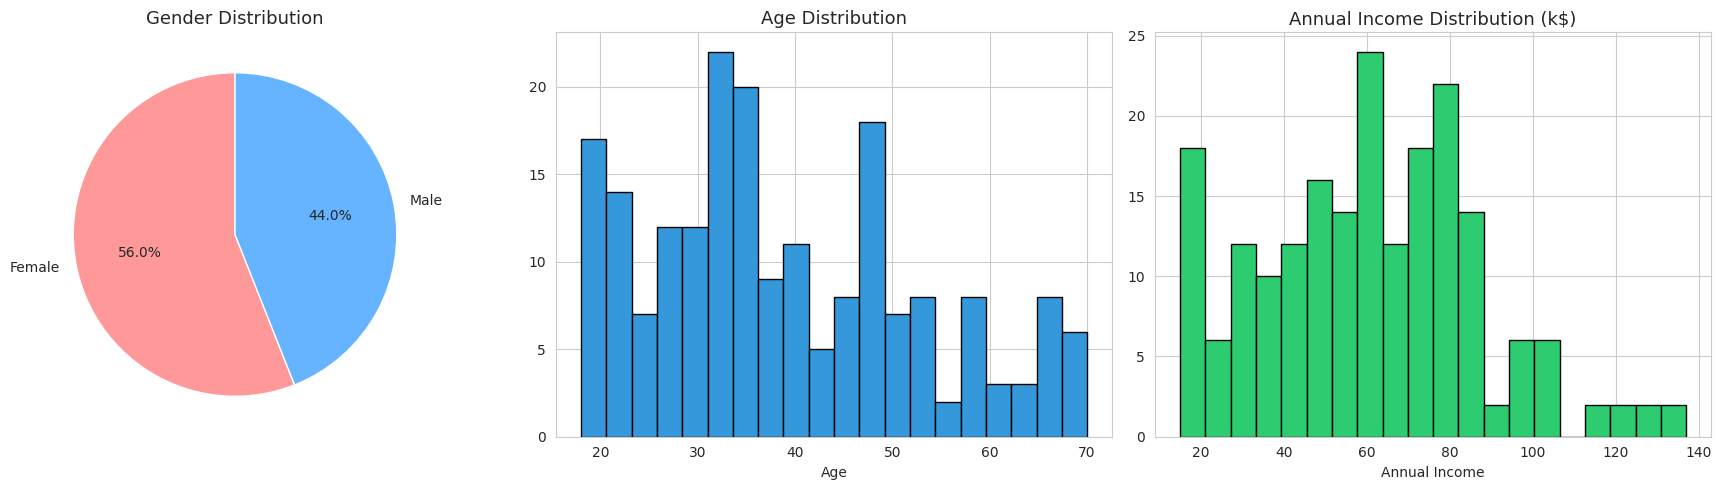

In [8]:
# Gender distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0],
                                  colors=['#ff9999','#66b3ff'], startangle=90)
axes[0].set_title('Gender Distribution', fontsize=13)
axes[0].set_ylabel('')

df['Age'].hist(bins=20, ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Age Distribution', fontsize=13)
axes[1].set_xlabel('Age')

df['Annual_Income'].hist(bins=20, ax=axes[2], color='#2ecc71', edgecolor='black')
axes[2].set_title('Annual Income Distribution (k$)', fontsize=13)
axes[2].set_xlabel('Annual Income')
plt.tight_layout()
plt.show()

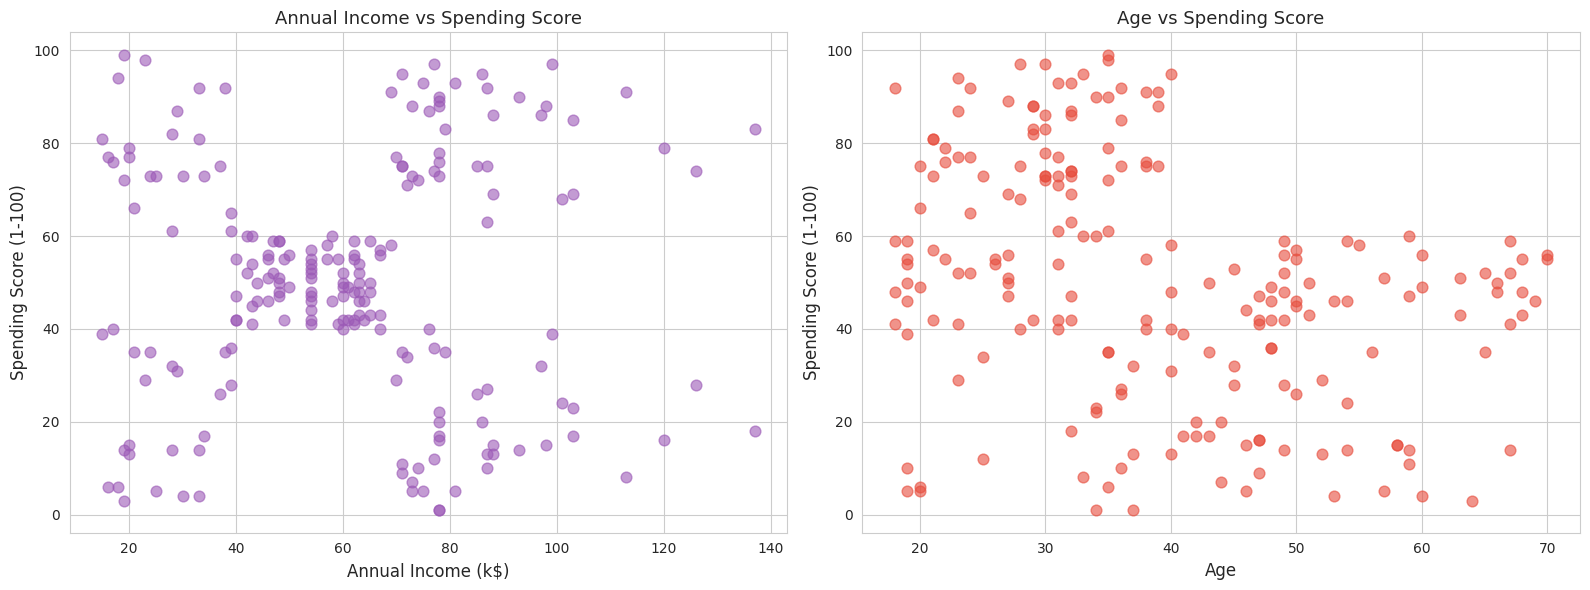

In [9]:
# Spending Score vs Annual Income scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['Annual_Income'], df['Spending_Score'], c='#9b59b6', alpha=0.6, s=60)
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title('Annual Income vs Spending Score', fontsize=13)

axes[1].scatter(df['Age'], df['Spending_Score'], c='#e74c3c', alpha=0.6, s=60)
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Age vs Spending Score', fontsize=13)
plt.tight_layout()
plt.show()

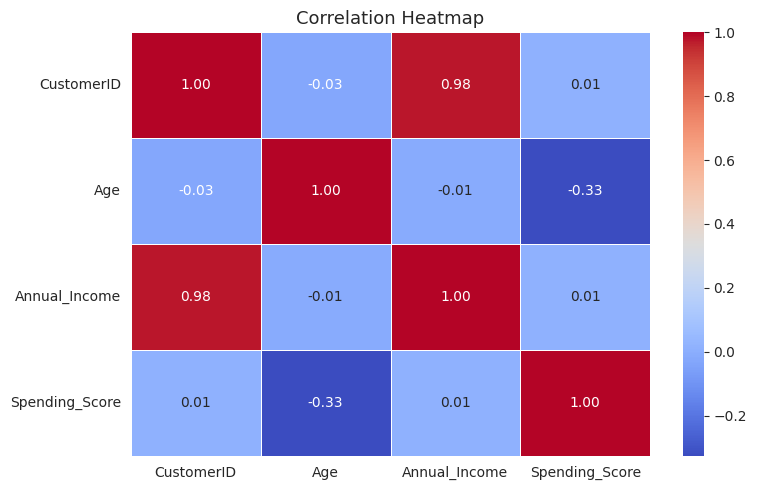

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 3. K-Means Clustering – Finding Optimal K (Elbow Method)

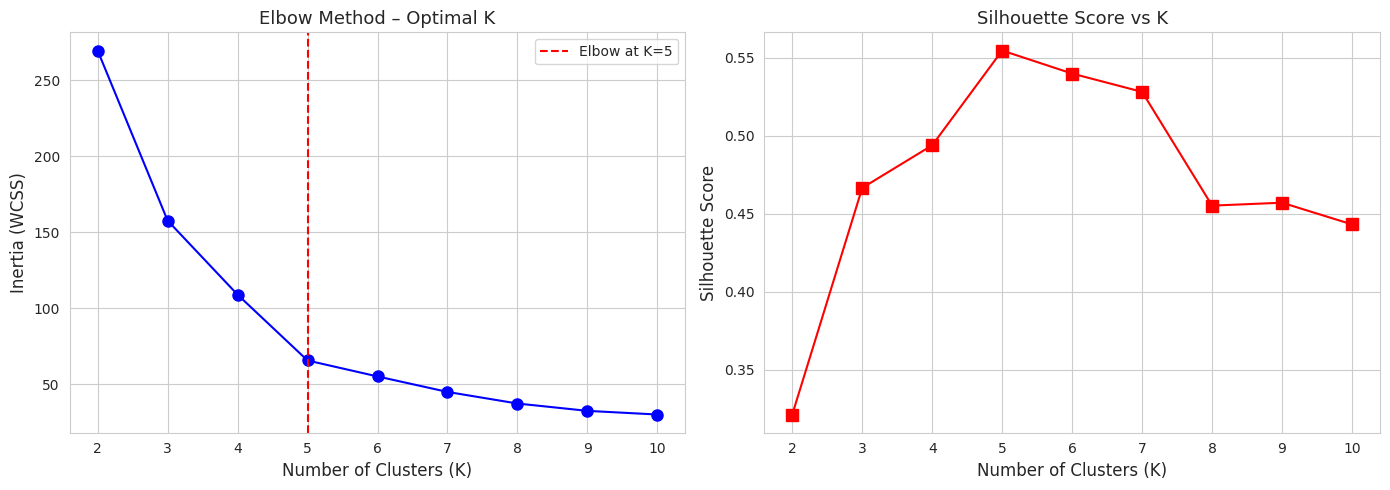

Optimal K = 5 (based on elbow and silhouette analysis)


In [11]:
# Use Annual Income and Spending Score for clustering
features = df[['Annual_Income', 'Spending_Score']]

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Elbow Method
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(features_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method – Optimal K', fontsize=13)
axes[0].axvline(x=5, color='red', linestyle='--', label='Elbow at K=5')
axes[0].legend()

axes[1].plot(K_range, silhouette, 'rs-', markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=13)
plt.tight_layout()
plt.show()
print('Optimal K = 5 (based on elbow and silhouette analysis)')

In [12]:
# Apply K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Cluster summary
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(1)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
print('Cluster Summary:')
print(cluster_summary)

Cluster Summary:
          Age  Annual_Income  Spending_Score  Count
Cluster                                            
0        42.7           55.3            49.5     81
1        32.7           86.5            82.1     39
2        25.3           25.7            79.4     22
3        41.1           88.2            17.1     35
4        45.2           26.3            20.9     23


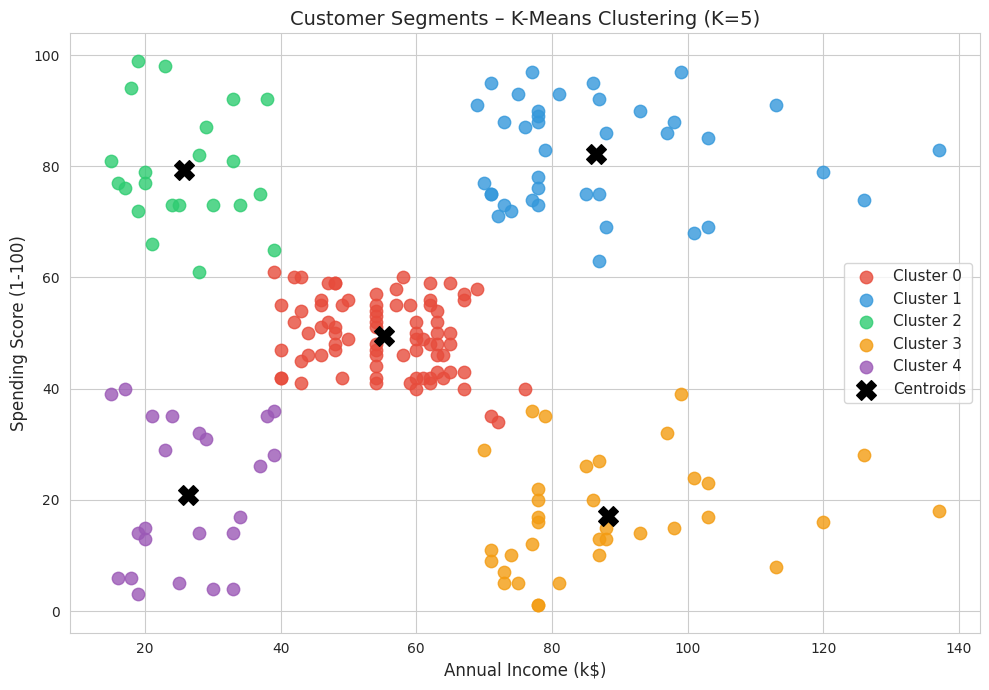

In [13]:
# Visualize clusters
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
labels = ['Cluster 0','Cluster 1','Cluster 2','Cluster 3','Cluster 4']

plt.figure(figsize=(10, 7))
for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                c=colors[i], label=labels[i], s=80, alpha=0.8)

# Plot centroids
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Segments – K-Means Clustering (K=5)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction – PCA & t-SNE

In [14]:
# Use all numeric features for PCA/t-SNE
all_features = df[['Age','Annual_Income','Spending_Score']]
all_scaled = StandardScaler().fit_transform(all_features)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(all_scaled)
print('t-SNE computed!')

PCA explained variance: [0.44266167 0.33308378]
Total variance explained: 77.6%
t-SNE computed!


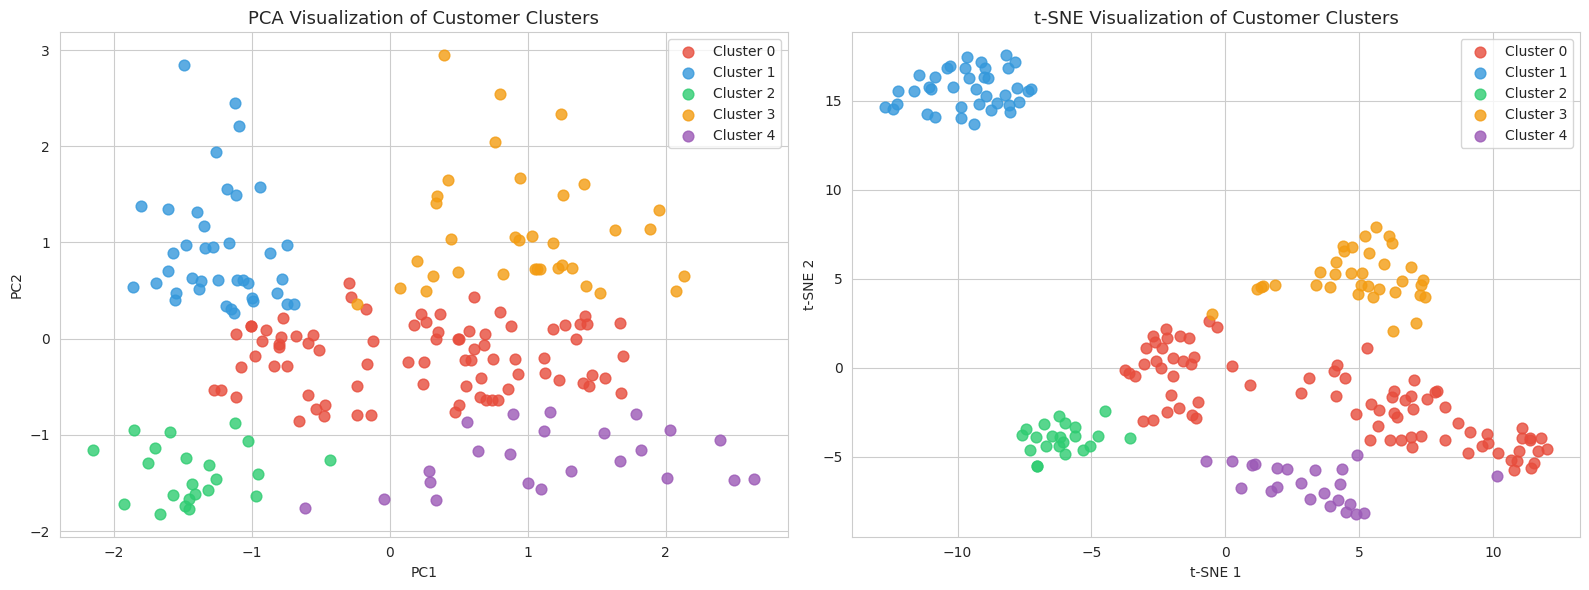

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(5):
    mask = df['Cluster'] == i
    axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1],
                    c=colors[i], label=f'Cluster {i}', s=60, alpha=0.8)
    axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=colors[i], label=f'Cluster {i}', s=60, alpha=0.8)

axes[0].set_title('PCA Visualization of Customer Clusters', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].set_title('t-SNE Visualization of Customer Clusters', fontsize=13)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()

plt.tight_layout()
plt.show()

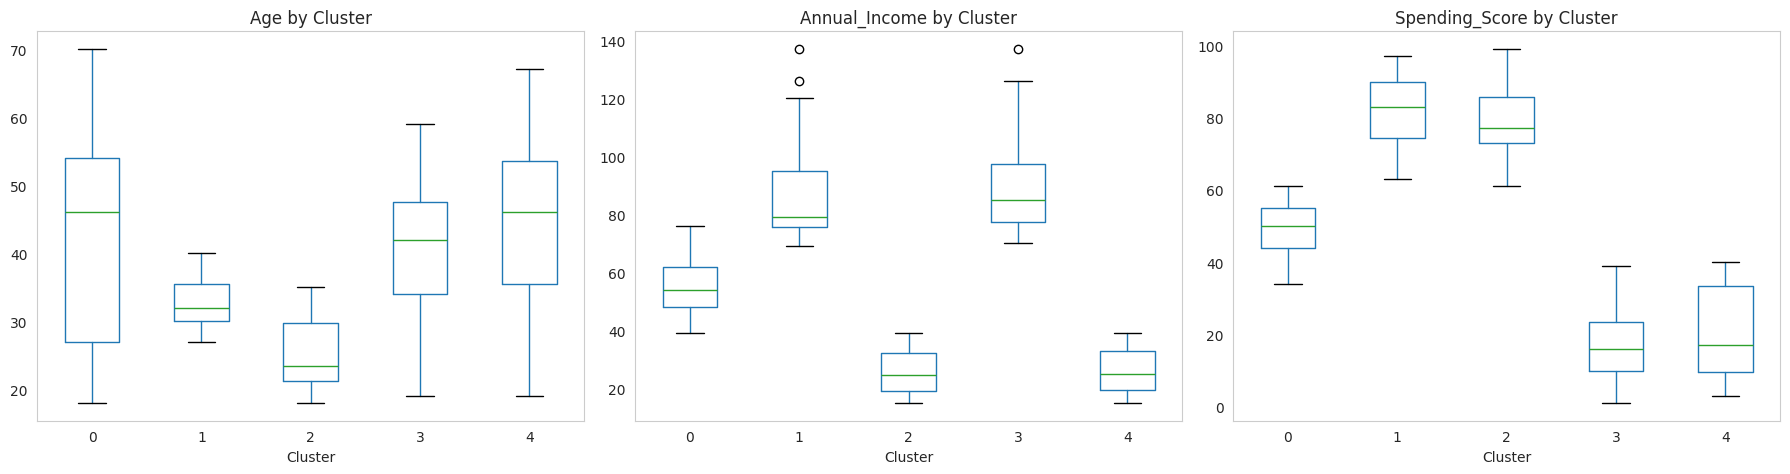

In [16]:
# Box plots per cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Age','Annual_Income','Spending_Score']):
    df.boxplot(column=col, by='Cluster', ax=ax, grid=False)
    ax.set_title(f'{col} by Cluster', fontsize=12)
    ax.set_xlabel('Cluster')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Cluster Profiles & Marketing Strategies

In [17]:
print('=== Customer Segment Profiles ===')
print(cluster_summary.to_string())
print()

strategies = {
    0: 'High Income, Low Spending  → "Premium Re-Engagement" – Offer exclusive loyalty rewards and personalized recommendations to convert high earners into high spenders.',
    1: 'Low Income, Low Spending   → "Budget Essentials" – Focus on affordable deals, discount campaigns, and value bundles. Not a priority for high-margin products.',
    2: 'Medium Income, Medium Spending → "Stable Loyalists" – Maintain engagement with regular newsletters, seasonal promotions, and loyalty points.',
    3: 'High Income, High Spending → "VIP Champions" – Offer premium memberships, early access to products, and concierge-level service. Highest revenue generators.',
    4: 'Low Income, High Spending  → "Impulsive Buyers" – Target with limited-time flash sales, trendy products, and FOMO-based marketing campaigns.'
}

print('=== Marketing Strategy Per Segment ===')
for cluster, strategy in strategies.items():
    print(f'\nCluster {cluster}: {strategy}')

=== Customer Segment Profiles ===
          Age  Annual_Income  Spending_Score  Count
Cluster                                            
0        42.7           55.3            49.5     81
1        32.7           86.5            82.1     39
2        25.3           25.7            79.4     22
3        41.1           88.2            17.1     35
4        45.2           26.3            20.9     23

=== Marketing Strategy Per Segment ===

Cluster 0: High Income, Low Spending  → "Premium Re-Engagement" – Offer exclusive loyalty rewards and personalized recommendations to convert high earners into high spenders.

Cluster 1: Low Income, Low Spending   → "Budget Essentials" – Focus on affordable deals, discount campaigns, and value bundles. Not a priority for high-margin products.

Cluster 2: Medium Income, Medium Spending → "Stable Loyalists" – Maintain engagement with regular newsletters, seasonal promotions, and loyalty points.

Cluster 3: High Income, High Spending → "VIP Champions" – Offe

## 6. Conclusion

### Clustering Results:
K-Means with K=5 produced clear, well-separated customer segments confirmed by both the Elbow Method and Silhouette Score analysis.

### The 5 Customer Segments:

| Cluster | Profile | Marketing Strategy |
|---|---|---|
| 0 | High Income, Low Spending | Premium Re-Engagement |
| 1 | Low Income, Low Spending | Budget Essentials |
| 2 | Medium Income, Medium Spending | Stable Loyalists |
| 3 | High Income, High Spending | VIP Champions |
| 4 | Low Income, High Spending | Impulsive Buyers |

### Dimensionality Reduction Insights:
Both PCA and t-SNE visualizations confirmed that the 5 clusters are well-separated in reduced feature space, validating the quality of the segmentation.

### Business Recommendation:
The mall should focus its premium marketing budget on Cluster 3 (VIP Champions) for maximum revenue, while running targeted re-engagement campaigns on Cluster 0 (High Income, Low Spending) to unlock their spending potential. Cluster 4 (Impulsive Buyers) represents an opportunity for flash-sale and trend-based campaigns.